In [ ]:
import math
import random as rnd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
import os
from matplotlib.ticker import NullFormatter
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from itertools import product
import tensorflow as tf
import tensorflow_probability as tfp
from tqdm import tqdm
import time
import torch.multiprocessing as mp
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn import metrics

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
hidden_dim=32

# data

In [ ]:
def auprc_threshs(confidences, Y, threshs, as_percentages=True):
  areas = []
  precisions, recalls, thresholds = metrics.precision_recall_curve(Y, confidences)
  for t in threshs:
    if t < 1.0:
      interp_prec_t = np.interp(t, recalls[::-1], precisions[::-1])
      recalls_thresh = np.concatenate(([t], recalls[recalls<t]))
      precisions_thresh = np.concatenate(([interp_prec_t], precisions[recalls<t]))
    else:
      recalls_thresh = recalls
      precisions_thresh = precisions
    area_t = metrics.auc(recalls_thresh, precisions_thresh)
    if as_percentages:
      area_t = area_t/t
    areas.append(area_t)
  return np.array(areas)

In [ ]:
data_path = '/content/gdrive/MyDrive/Scientific_Discovery/chem_ood_datasets/'

In [ ]:
tdc_path = '/content/gdrive/MyDrive/Scientific_Discovery/chem_ood_datasets/TDC_datasets/'

In [ ]:
def data_preproc(data_name, home_path= data_path) :
  df_train=pd.read_csv(home_path + data_name + '/train.csv')
  df_test_id=pd.read_csv(home_path + data_name + '/test_id.csv')
  df_test_ood=pd.read_csv(home_path + data_name + '/test_ood.csv')
  df_val_id=pd.read_csv(home_path + data_name + '/val_id.csv')
  df_val_ood=pd.read_csv(home_path + data_name + '/val_ood.csv')
  fps_dim = df_train.shape[1] - 2
  X_cols = []
  for i in range(1, fps_dim + 1):
    X_cols.append("fp_" + str(i))
  X_train = df_train.loc[:, X_cols].values
  y_train = df_train.Label.values
  X_test_id = df_test_id.loc[:, X_cols].values
  y_test_id = df_test_id.Label.values
  X_test_ood = df_test_ood.loc[:, X_cols].values
  y_test_ood = df_test_ood.Label.values
  X_val_id = df_val_id.loc[:, X_cols].values
  y_val_id = df_val_id.Label.values
  X_val_ood = df_val_ood.loc[:, X_cols].values
  y_val_ood = df_val_ood.Label.values
  data_dict = {'train' : [X_train, y_train],
               'test_id' : [X_test_id, y_test_id],
               'test_ood' : [X_test_ood, y_test_ood],
               'val_id' : [X_val_id, y_val_id],
               'val_ood' : [X_val_ood, y_val_ood]}

  X_train = data_dict["train"][0]
  y_train = data_dict["train"][1].astype(float)

  #in-distribution test data
  X_test_id = data_dict["test_id"][0]
  y_test_id = data_dict["test_id"][1].astype(float)
  #ood test data
  X_test_ood = data_dict["test_ood"][0]
  y_test_ood = data_dict["test_ood"][1].astype(float)

  #in-distribution validation data
  X_val_id = data_dict["val_id"][0]
  y_val_id = data_dict["val_id"][1].astype(float)
  #ood valication data
  X_val_ood = data_dict["val_ood"][0]
  y_val_ood = data_dict["val_ood"][1].astype(float)

  return X_train, y_train, X_test_id, y_test_id, X_test_ood, y_test_ood, X_val_id, y_val_id, X_val_ood, y_val_ood, fps_dim

In [ ]:
# X_train, y_train, X_test_id, y_test_id, X_test_ood, y_test_ood, X_val_id, y_val_id, X_val_ood, y_val_ood, fps_dim = data_preproc("dataset1")

In [ ]:
def find_perturbation(X, y, model_1, model_2, eps, alpha, iters, clamp_val=None, rs=True, use_grad_sign=False, normalize_grad=False):
  delta = torch.zeros_like(X).to(X.device)
  if rs:
    delta.uniform_(-eps, eps)

  delta.requires_grad = True
  for _ in range(iters):
    delta.grad = None
    if clamp_val is not None:
      X_ = torch.clamp(X + delta, clamp_val[0], clamp_val[1])
    else:
      X_ = X + delta
    p_1 = torch.sigmoid(model_1(X_))
    p_2 = torch.sigmoid(model_2(X_))
    loss = ( (1.-p_1) * p_2 + p_1 * (1.-p_2)).log().mean()

    loss.backward()
    grad = delta.grad.detach()

    if normalize_grad:
      grad /= grad.norm()

    if use_grad_sign:
      grad = grad.sign()

    delta.data = (delta + alpha * grad)
    if clamp_val is not None:
      delta.data = torch.clamp(X + delta.data, clamp_val[0], clamp_val[1]) - X
    delta.data = torch.clamp(delta.data, -eps, eps)

  return delta.detach()


@torch.no_grad()
def get_acc(model, dl):
  model.eval()
  acc = []
  for X, y in dl:
    acc.append((torch.sigmoid(model(X)) > 0.5) == y)
  acc = torch.cat(acc)
  acc = torch.sum(acc)/len(acc)
  model.train()
  return acc.item()

In [ ]:
def data_preproc_TDC(data_name) :
  df_train=pd.read_csv('/content/gdrive/MyDrive/LUPA_Lab/Chem_ML/TDC_datasets/' + data_name + '/train.csv')
  df_test_id=pd.read_csv('/content/gdrive/MyDrive/LUPA_Lab/Chem_ML/TDC_datasets/' + data_name + '/test_id.csv')
  df_test_ood=pd.read_csv('/content/gdrive/MyDrive/LUPA_Lab/Chem_ML/TDC_datasets/' + data_name + '/test_ood.csv')
  df_val_id=pd.read_csv('/content/gdrive/MyDrive/LUPA_Lab/Chem_ML/TDC_datasets/' + data_name + '/val_id.csv')
  df_val_ood=pd.read_csv('/content/gdrive/MyDrive/LUPA_Lab/Chem_ML/TDC_datasets/' + data_name + '/val_ood.csv')
  fps_dim = df_train.shape[1] - 2
  X_cols = []
  for i in range(1, fps_dim + 1):
    X_cols.append("fp_" + str(i))
  X_train = df_train.loc[:, X_cols].values
  y_train = df_train.Label.values
  X_test_id = df_test_id.loc[:, X_cols].values
  y_test_id = df_test_id.Label.values
  X_test_ood = df_test_ood.loc[:, X_cols].values
  y_test_ood = df_test_ood.Label.values
  X_val_id = df_val_id.loc[:, X_cols].values
  y_val_id = df_val_id.Label.values
  X_val_ood = df_val_ood.loc[:, X_cols].values
  y_val_ood = df_val_ood.Label.values
  data_dict = {'train' : [X_train, y_train],
               'test_id' : [X_test_id, y_test_id],
               'test_ood' : [X_test_ood, y_test_ood],
               'val_id' : [X_val_id, y_val_id],
               'val_ood' : [X_val_ood, y_val_ood]}

  X_train = data_dict["train"][0]
  y_train = data_dict["train"][1]

  #in-distribution test data
  X_test_id = data_dict["test_id"][0]
  y_test_id = data_dict["test_id"][1]
  #ood test data
  X_test_ood = data_dict["test_ood"][0]
  y_test_ood = data_dict["test_ood"][1]

  #in-distribution validation data
  X_val_id = data_dict["val_id"][0]
  y_val_id = data_dict["val_id"][1]
  #ood valication data
  X_val_ood = data_dict["val_ood"][0]
  y_val_ood = data_dict["val_ood"][1]

  return X_train, y_train, X_test_id, y_test_id, X_test_ood, y_test_ood, X_val_id, y_val_id, X_val_ood, y_val_ood, fps_dim

In [ ]:
def integrate(x, y, rec):
   x = [t for t in x if t!=0]
   y = [t for t in y if ~np.isnan(t)]
   sm = 0
   if x[0] >= rec:
     return rec * y[0]
   sm += x[0] * y[0]

   for i in range(1, len(x)):
    if x[i] > rec:
      h = rec - x[i - 1]
      sm += h * (y[i-1] + y[i]) / 2
      break
    # if i == 0:
    #   sm += x[i] * y [i]
    # else:
    h = x[i] - x[i - 1]

    sm += h * ((y[i-1] + y[i]) / 2)

   return sm

# DBAT emseble training


In [ ]:
X_train, y_train, X_test_id, y_test_id, X_test_ood, y_test_ood, X_val_id, y_val_id, X_val_ood, y_val_ood, fps_dim = data_preproc("ames_mutagenicity", home_path=tdc_path)

In [ ]:
X_train.shape

(3597, 1024)

In [ ]:
#standardize
mu_x = np.mean(X_train, 0, keepdims=True)
#sigma_x = np.std(X, 0, keepdims=True)
sigma_x = np.ones_like(mu_x)
X = (X_train-mu_x)/sigma_x
external_X = (X_val_ood-mu_x)/sigma_x

# PCA
XtX = np.matmul(X.T, X)
eigvals, eigvecs = np.linalg.eig(XtX)
sortinds = np.argsort(-eigvals)
V = eigvecs[:, sortinds]


NDIRS = 128  # 256
X = X@V[:, :NDIRS]
external_X = external_X@V[:, :NDIRS]

In [ ]:
def find_perturbation(X, y, model_1, model_2, eps, alpha, iters, clamp_val=None, rs=True, use_grad_sign=False, normalize_grad=False):
  delta = torch.zeros_like(X).to(X.device)
  if rs:
    delta.uniform_(-eps, eps)

  delta.requires_grad = True
  for _ in range(iters):
    delta.grad = None
    if clamp_val is not None:
      X_ = torch.clamp(X + delta, clamp_val[0], clamp_val[1])
    else:
      X_ = X + delta
    p_1 = torch.sigmoid(model_1(X_))
    p_2 = torch.sigmoid(model_2(X_))
    loss = ( (1.-p_1) * p_2 + p_1 * (1.-p_2)).log().mean()

    loss.backward()
    grad = delta.grad.detach()

    if normalize_grad:
      grad /= grad.norm()

    if use_grad_sign:
      grad = grad.sign()

    delta.data = (delta + alpha * grad)
    if clamp_val is not None:
      delta.data = torch.clamp(X + delta.data, clamp_val[0], clamp_val[1]) - X
    delta.data = torch.clamp(delta.data, -eps, eps)

  return delta.detach()


@torch.no_grad()
def get_acc(model, dl):
  model.eval()
  acc = []
  for X, y in dl:
    acc.append((torch.sigmoid(model(X)) > 0.5) == y)
  acc = torch.cat(acc)
  acc = torch.sum(acc)/len(acc)
  model.train()
  return acc.item()

In [ ]:
X.shape

(3597, 128)

In [ ]:
def train_D_Bat(X_train, Y_train, epochs=10):
  #data loader
  train_dataset = torch.utils.data.TensorDataset(torch.tensor(X_train).to(torch.float32), torch.tensor(Y_train).view(-1,1))
  train_dl = DataLoader(train_dataset, batch_size=64, shuffle=True)
  fps_dim = X_train.shape[1]

  #ERM model1
  model_1 = nn.Sequential(nn.Linear(fps_dim,hidden_dim), nn.LeakyReLU(), nn.Linear(hidden_dim,1))
  opt = torch.optim.Adam(model_1.parameters(), lr=0.01)
  print('training m1')
  stats = {'erm_m1': [], 'erm_m2': [], 'adv_loss': []}
  for epoch in range(epochs):
    for itr, (x, y) in enumerate(train_dl):

      erm_m1 = F.binary_cross_entropy_with_logits(model_1(x), y)
      stats['erm_m1'].append((itr + epoch * len(train_dl), erm_m1.item()))
      erm_loss = erm_m1 # ERM

      loss = erm_loss

      opt.zero_grad()
      loss.backward()
      opt.step()

  #ADV model2
  print('training m2')
  ALPHA = 0.01
  model_2 = nn.Sequential(nn.Linear(fps_dim,hidden_dim), nn.LeakyReLU(), nn.Linear(hidden_dim,1))
  opt = torch.optim.Adam(model_2.parameters(), lr=0.01)
  for epoch in range(epochs):
    for itr, (x, y) in enumerate(train_dl):
      erm_loss = F.binary_cross_entropy_with_logits(model_2(x), y)
      delta = find_perturbation(x, y, model_1, model_2, eps=1.0, alpha=0.1, iters=15, use_grad_sign=True)
      x_tilde = x + delta
      with torch.no_grad():
        p_1 = torch.sigmoid(model_1(x_tilde))
      p_2 = torch.sigmoid(model_2(x_tilde))
      adv_loss = - ((1.-p_1) * p_2 + p_1 * (1.-p_2) + 1e-5).log().mean()
      loss = erm_loss + ALPHA * adv_loss
      opt.zero_grad()
      loss.backward()
      opt.step()
      if (itr + epoch * len(train_dl)) % 200 == 0:
        print_str = f"{itr + epoch * len(train_dl)} -\t [train] loss: {loss.item():.2f} "
        train_acc_1 = get_acc(model_1, train_dl)
        print_str += f"[m1] acc: {train_acc_1:.2f} "
        train_acc_2 = get_acc(model_2, train_dl)
        print_str += f"[m2] acc: {train_acc_2:.2f} "
        print(print_str)

  #adv model3
  model_3 = nn.Sequential(nn.Linear(fps_dim,hidden_dim), nn.LeakyReLU(), nn.Linear(hidden_dim,1))
  opt = torch.optim.Adam(model_3.parameters(), lr=0.01)
  for epoch in range(epochs):
    for itr, (x, y) in enumerate(train_dl):
      erm_loss = F.binary_cross_entropy_with_logits(model_3(x), y)
      delta_1 = find_perturbation(x, y, model_1, model_3, eps=1.0, alpha=0.1, iters=15, use_grad_sign=True)
      x_tilde_1 = x + delta_1
      delta_2 = find_perturbation(x, y, model_2, model_3, eps=1.0, alpha=0.1, iters=15, use_grad_sign=True)
      x_tilde_2 = x + delta_2
      with torch.no_grad():
        p_1 = torch.sigmoid(model_1(x_tilde_1))
        p_2 = torch.sigmoid(model_2(x_tilde_2))
      p_3_1 = torch.sigmoid(model_3(x_tilde_1))
      p_3_2 = torch.sigmoid(model_3(x_tilde_2))
      adv_loss = - (1/2) * (((1.-p_1) * p_3_1 + p_1 * (1.-p_3_1) + 1e-5).log().mean() + ((1.-p_2) * p_3_2 + p_2 * (1.-p_3_2) + 1e-5).log().mean())
      loss = erm_loss + ALPHA * adv_loss
      opt.zero_grad()
      loss.backward()
      opt.step()
      if (itr + epoch * len(train_dl)) % 200 == 0:
        print_str = f"{itr + epoch * len(train_dl)} -\t [train] loss: {loss.item():.2f} "
        train_acc_1 = get_acc(model_1, train_dl)
        print_str += f"[m1] acc: {train_acc_1:.2f} "
        train_acc_2 = get_acc(model_2, train_dl)
        print_str += f"[m2] acc: {train_acc_2:.2f} "
        train_acc_3 = get_acc(model_3, train_dl)
        print_str += f"[m3] acc: {train_acc_3:.2f} "
        print(print_str)

  #adv model4
  print('training m4')
  model_4 = nn.Sequential(nn.Linear(fps_dim,hidden_dim), nn.LeakyReLU(), nn.Linear(hidden_dim,1))
  opt = torch.optim.Adam(model_4.parameters(), lr=0.01)

  for epoch in range(epochs):
    for itr, (x, y) in enumerate(train_dl):

      erm_loss = F.binary_cross_entropy_with_logits(model_4(x), y)

      delta_1 = find_perturbation(x, y, model_1, model_4, eps=1.0, alpha=0.1, iters=15, use_grad_sign=True)
      x_tilde_1 = x + delta_1
      delta_2 = find_perturbation(x, y, model_2, model_4, eps=1.0, alpha=0.1, iters=15, use_grad_sign=True)
      x_tilde_2 = x + delta_2
      delta_3 = find_perturbation(x, y, model_3, model_4, eps=1.0, alpha=0.1, iters=15, use_grad_sign=True)
      x_tilde_3 = x + delta_3
      with torch.no_grad():
        p_1 = torch.sigmoid(model_1(x_tilde_1))
        p_2 = torch.sigmoid(model_2(x_tilde_2))
        p_3 = torch.sigmoid(model_3(x_tilde_3))
      p_4_1 = torch.sigmoid(model_4(x_tilde_1))
      p_4_2 = torch.sigmoid(model_4(x_tilde_2))
      p_4_3 = torch.sigmoid(model_4(x_tilde_3))
      adv_loss = - (1/3) * (((1.-p_1) * p_4_1 + p_1 * (1.-p_4_1) + 1e-5).log().mean() + ((1.-p_2) * p_4_2 + p_2 * (1.-p_4_2) + 1e-5).log().mean() + + ((1.-p_3) * p_4_3 + p_3 * (1.-p_4_3) + 1e-5).log().mean())

      loss = erm_loss + ALPHA * adv_loss

      opt.zero_grad()
      loss.backward()
      opt.step()

      if (itr + epoch * len(train_dl)) % 200 == 0:
        print_str = f"{itr + epoch * len(train_dl)} -\t [train] loss: {loss.item():.2f} "
        train_acc_1 = get_acc(model_1, train_dl)
        print_str += f"[m1] acc: {train_acc_1:.2f} "
        train_acc_2 = get_acc(model_2, train_dl)
        print_str += f"[m2] acc: {train_acc_2:.2f} "
        train_acc_3 = get_acc(model_3, train_dl)
        print_str += f"[m3] acc: {train_acc_3:.2f} "
        train_acc_4 = get_acc(model_4, train_dl)
        print_str += f"[m4] acc: {train_acc_4:.2f} "
        print(print_str)

  #adv model5
  print('training m5')
  model_5 = nn.Sequential(nn.Linear(fps_dim,hidden_dim), nn.LeakyReLU(), nn.Linear(hidden_dim,1))
  opt = torch.optim.Adam(model_5.parameters(), lr=0.01)
  for epoch in range(epochs):
    for itr, (x, y) in enumerate(train_dl):

      erm_loss = F.binary_cross_entropy_with_logits(model_5(x), y)

      delta_1 = find_perturbation(x, y, model_1, model_5, eps=1.0, alpha=0.1, iters=15, use_grad_sign=True)
      x_tilde_1 = x + delta_1
      delta_2 = find_perturbation(x, y, model_2, model_5, eps=1.0, alpha=0.1, iters=15, use_grad_sign=True)
      x_tilde_2 = x + delta_2
      delta_3 = find_perturbation(x, y, model_3, model_5, eps=1.0, alpha=0.1, iters=15, use_grad_sign=True)
      x_tilde_3 = x + delta_3
      delta_4 = find_perturbation(x, y, model_4, model_5, eps=1.0, alpha=0.1, iters=15, use_grad_sign=True)
      x_tilde_4 = x + delta_4
      with torch.no_grad():
        p_1 = torch.sigmoid(model_1(x_tilde_1))
        p_2 = torch.sigmoid(model_2(x_tilde_2))
        p_3 = torch.sigmoid(model_3(x_tilde_3))
        p_4 = torch.sigmoid(model_4(x_tilde_4))
      p_5_1 = torch.sigmoid(model_5(x_tilde_1))
      p_5_2 = torch.sigmoid(model_5(x_tilde_2))
      p_5_3 = torch.sigmoid(model_5(x_tilde_3))
      p_5_4 = torch.sigmoid(model_5(x_tilde_4))
      adv_loss = - (1/4) * (((1.-p_1) * p_5_1 + p_1 * (1.-p_5_1) + 1e-5).log().mean() +\
                            ((1.-p_2) * p_5_2 + p_2 * (1.-p_5_2) + 1e-5).log().mean() +\
                            ((1.-p_3) * p_5_3 + p_3 * (1.-p_5_3) + 1e-5).log().mean() +\
                            ((1.-p_4) * p_5_4 + p_4 * (1.-p_5_4) + 1e-5).log().mean())

      loss = erm_loss + ALPHA * adv_loss

      opt.zero_grad()
      loss.backward()
      opt.step()

      if (itr + epoch * len(train_dl)) % 200 == 0:

        print_str = f"{itr + epoch * len(train_dl)} -\t [train] loss: {loss.item():.2f} "
        train_acc_1 = get_acc(model_1, train_dl)
        print_str += f"[m1] acc: {train_acc_1:.2f} "
        train_acc_2 = get_acc(model_2, train_dl)
        print_str += f"[m2] acc: {train_acc_2:.2f} "
        train_acc_3 = get_acc(model_3, train_dl)
        print_str += f"[m3] acc: {train_acc_3:.2f} "
        train_acc_4 = get_acc(model_4, train_dl)
        print_str += f"[m4] acc: {train_acc_4:.2f} "
        train_acc_5 = get_acc(model_5, train_dl)
        print_str += f"[m5] acc: {train_acc_5:.2f} "
        print(print_str)
  # model_1.eval()
  # model_2.eval()
  # model_3.eval()
  # model_4.eval()
  # model_5.eval()
  return [model_1, model_2, model_3, model_4, model_5]

In [ ]:
def D_Bat_Ensemble_predict(test_X, Vpca, di_list, emsemble, binary = True):
  #models is list of Dbat models [[dbat1], [dbat2], [dbat3]...]
  l1 = range(len(emsemble[0]))
  combos = list(product(l1, l1))

  emsemble_probs = []
  with torch.no_grad():
    for i in range(len(emsemble)):
      models = emsemble[i]
      di = di_list[i]

      for model in models:
        model.eval()
      test_dataset = torch.utils.data.TensorDataset(torch.tensor(test_X@ Vpca[:, di]).to(torch.float32))
      test_dl = DataLoader(test_dataset, batch_size=64)
      probs = []
      diffs = []
      for x, in test_dl:
        outs = [model(x) for model in models]
        ps = [torch.sigmoid(torch.tensor(out)) for out in outs]
        diff = 0
        for comb in combos:
          diff += abs(torch.sigmoid(torch.tensor(outs[comb[0]])) - torch.sigmoid(torch.tensor(outs[comb[1]])))
        mean_ps = torch.stack(ps).mean(dim=0)
        probs.append(mean_ps)
        diffs.append(diff)
      diffs = torch.cat(diffs)
      probs = torch.cat(probs)
      if binary:
        emsemble_probs.append((probs.flatten()>0.5).numpy().astype(np.float32))
      else:
        emsemble_probs.append(probs.flatten())
  return np.array(emsemble_probs).T

In [ ]:
# models = train_D_Bat(X, y_train)

In [ ]:
external_X.shape

(727, 128)

In [ ]:
def train_dbat_ensemble_sequential(X, Y, Vpca, nmodels=16, ndirs=8, projection_split=False, split_perc=0.5):
    Bbats = []
    dirs_list = []
    splits_list = []

    XV = X @ Vpca
    N, d = X.shape

    for i in tqdm(range(nmodels), desc="Training D_Bat ensemble"):
        seed = np.random.randint(0, 1e9)
        np.random.seed(seed)

        if projection_split:
            newdir = np.random.randn(d, 1)
            newdir = newdir/np.sqrt(np.sum(newdir**2))
            projs = (X@newdir)[:, 0]
            in_range = projs <= np.median(projs)
        else:
            in_range = np.random.rand(N) <= split_perc

        Y_train = Y[in_range]
        rprm = np.random.permutation(Vpca.shape[1])
        dir_inds = rprm[:ndirs]
        X_train = XV[in_range][:, dir_inds]

        model = train_D_Bat(X_train, Y_train)

        Bbats.append(model)
        dirs_list.append(dir_inds)
        splits_list.append(in_range)

    return Bbats, dirs_list, splits_list

In [ ]:
Bbats, dirs_list, splits_list = train_dbat_ensemble_sequential(
    X,
    y_train,
    Vpca=np.eye(NDIRS, dtype=np.float32),
    nmodels=16,
    ndirs=64,
    projection_split=True,
    split_perc=0.5
)

Training D_Bat ensemble:   0%|          | 0/16 [00:00<?, ?it/s]

training m1
training m2
0 -	 [train] loss: 0.66 [m1] acc: 0.88 [m2] acc: 0.62 
200 -	 [train] loss: 0.40 [m1] acc: 0.88 [m2] acc: 0.86 
0 -	 [train] loss: 0.68 [m1] acc: 0.88 [m2] acc: 0.89 [m3] acc: 0.61 
200 -	 [train] loss: 0.32 [m1] acc: 0.88 [m2] acc: 0.89 [m3] acc: 0.85 
training m4
0 -	 [train] loss: 0.67 [m1] acc: 0.88 [m2] acc: 0.89 [m3] acc: 0.90 [m4] acc: 0.65 
200 -	 [train] loss: 0.38 [m1] acc: 0.88 [m2] acc: 0.89 [m3] acc: 0.90 [m4] acc: 0.86 
training m5
0 -	 [train] loss: 0.76 [m1] acc: 0.88 [m2] acc: 0.89 [m3] acc: 0.90 [m4] acc: 0.89 [m5] acc: 0.51 
200 -	 [train] loss: 0.50 [m1] acc: 0.88 [m2] acc: 0.89 [m3] acc: 0.90 [m4] acc: 0.89 [m5] acc: 0.86 


Training D_Bat ensemble:   6%|▋         | 1/16 [00:46<11:33, 46.20s/it]

training m1
training m2
0 -	 [train] loss: 0.70 [m1] acc: 0.87 [m2] acc: 0.48 
200 -	 [train] loss: 0.39 [m1] acc: 0.87 [m2] acc: 0.84 
0 -	 [train] loss: 0.71 [m1] acc: 0.87 [m2] acc: 0.85 [m3] acc: 0.53 
200 -	 [train] loss: 0.45 [m1] acc: 0.87 [m2] acc: 0.85 [m3] acc: 0.85 
training m4
0 -	 [train] loss: 0.73 [m1] acc: 0.87 [m2] acc: 0.85 [m3] acc: 0.86 [m4] acc: 0.50 
200 -	 [train] loss: 0.30 [m1] acc: 0.87 [m2] acc: 0.85 [m3] acc: 0.86 [m4] acc: 0.83 
training m5
0 -	 [train] loss: 0.69 [m1] acc: 0.87 [m2] acc: 0.85 [m3] acc: 0.86 [m4] acc: 0.85 [m5] acc: 0.58 
200 -	 [train] loss: 0.38 [m1] acc: 0.87 [m2] acc: 0.85 [m3] acc: 0.86 [m4] acc: 0.85 [m5] acc: 0.85 


Training D_Bat ensemble:  12%|█▎        | 2/16 [01:29<10:22, 44.48s/it]

...

Training D_Bat ensemble:  88%|████████▊ | 14/16 [10:09<01:26, 43.18s/it]

training m1
training m2
0 -	 [train] loss: 0.66 [m1] acc: 0.88 [m2] acc: 0.59 
200 -	 [train] loss: 0.36 [m1] acc: 0.88 [m2] acc: 0.84 
0 -	 [train] loss: 0.68 [m1] acc: 0.88 [m2] acc: 0.89 [m3] acc: 0.60 
200 -	 [train] loss: 0.47 [m1] acc: 0.88 [m2] acc: 0.89 [m3] acc: 0.85 
training m4
0 -	 [train] loss: 0.71 [m1] acc: 0.88 [m2] acc: 0.89 [m3] acc: 0.89 [m4] acc: 0.54 
200 -	 [train] loss: 0.33 [m1] acc: 0.88 [m2] acc: 0.89 [m3] acc: 0.89 [m4] acc: 0.85 
training m5
0 -	 [train] loss: 0.71 [m1] acc: 0.88 [m2] acc: 0.89 [m3] acc: 0.89 [m4] acc: 0.87 [m5] acc: 0.53 
200 -	 [train] loss: 0.39 [m1] acc: 0.88 [m2] acc: 0.89 [m3] acc: 0.89 [m4] acc: 0.87 [m5] acc: 0.85 


Training D_Bat ensemble:  94%|█████████▍| 15/16 [10:52<00:43, 43.13s/it]

training m1
training m2
0 -	 [train] loss: 0.72 [m1] acc: 0.91 [m2] acc: 0.50 
200 -	 [train] loss: 0.33 [m1] acc: 0.91 [m2] acc: 0.89 
0 -	 [train] loss: 0.70 [m1] acc: 0.91 [m2] acc: 0.91 [m3] acc: 0.55 
200 -	 [train] loss: 0.43 [m1] acc: 0.91 [m2] acc: 0.91 [m3] acc: 0.89 
training m4
0 -	 [train] loss: 0.70 [m1] acc: 0.91 [m2] acc: 0.91 [m3] acc: 0.93 [m4] acc: 0.57 
200 -	 [train] loss: 0.30 [m1] acc: 0.91 [m2] acc: 0.91 [m3] acc: 0.93 [m4] acc: 0.88 
training m5
0 -	 [train] loss: 0.69 [m1] acc: 0.91 [m2] acc: 0.91 [m3] acc: 0.93 [m4] acc: 0.92 [m5] acc: 0.53 
200 -	 [train] loss: 0.41 [m1] acc: 0.91 [m2] acc: 0.91 [m3] acc: 0.93 [m4] acc: 0.92 [m5] acc: 0.89 


Training D_Bat ensemble: 100%|██████████| 16/16 [11:35<00:00, 43.48s/it]


In [ ]:
results = D_Bat_Ensemble_predict(external_X, Vpca=np.eye(NDIRS, dtype=np.float32), di_list=dirs_list, emsemble=Bbats)

/tmp/ipython-input-2129595605.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ps = [torch.sigmoid(torch.tensor(out)) for out in outs]
/tmp/ipython-input-2129595605.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  diff += abs(torch.sigmoid(torch.tensor(outs[comb[0]])) - torch.sigmoid(torch.tensor(outs[comb[1]])))


In [ ]:
np.array(results).shape

(727, 16)

In [ ]:
np.array(results)

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 1., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [ ]:
mean_probs_ens = np.mean(np.array(results), axis=1)

In [ ]:
threshs = [0.1, 0.2, 0.3, 0.4, 1]

In [ ]:
auprc_threshs(mean_probs_ens, y_val_ood, threshs, as_percentages=True)

array([0.99058742, 0.98166679, 0.97336567, 0.9689029 , 0.88430116])

# emoe func

In [ ]:
def knn_gibbs(Xsamp, X, nn_featinds, k):
  Xf = X[:, nn_featinds]
  Xsf = Xsamp[:, nn_featinds]
  Xfnorm2 = np.sum(Xf**2, keepdims=True)
  Xsfnorm2 = np.sum(Xsf**2, keepdims=True)
  dotsf = Xsf@Xf.T
  distsf = Xsfnorm2 + Xfnorm2.T - 2*dotsf
  sortdistsf = np.argsort(distsf, axis=1)
  # neighs = sortdistsf[:, np.random.choice(k, size=(X.shape[0], ))]
  neighs = sortdistsf[np.arange(Xsamp.shape[0]), np.random.choice(k, size=(X.shape[0], ))]
  Xsamp = np.copy(Xsamp)
  Xsamp[:, np.logical_not(nn_featinds)] = X[neighs, :][:, np.logical_not(nn_featinds)]
  return Xsamp

def gibbs_sample(X, k, nrounds):
  Xsamp = X
  for r in range(nrounds):
    featinds = np.random.rand(X.shape[1])<.5
    Xsamp = knn_gibbs(Xsamp, X, featinds, k)
    Xsamp = knn_gibbs(Xsamp, X, np.logical_not(featinds), k)
  return Xsamp

def permute_expand(X):
  N, d = X.shape
  return np.stack([X[np.random.permutation(N), i] for i in range(d)], -1)

def convex_expand(X):
  N, d = X.shape
  X1 = X[np.random.permutation(N), :]
  alphas = np.random.rand(N, 1)
  return alphas*X + (1-alphas)*X1

In [ ]:
expand_funcs = [
    # lambda x: gibbs_sample(x, 40, 2),
    # lambda x: permute_expand(x),
    # lambda x: convex_expand(x),
    lambda x: x*(1+np.abs(np.random.randn(x.shape[0], 1)))
]

In [ ]:
class DatasetDiscriminator(tf.keras.Model):
  def __init__(self, dim, nhidden_layers=2, hidden_size=256, out_size=64, net=None):
    super(DatasetDiscriminator, self).__init__()

    self.dim = dim
    if net is not None:
      self.net = net
    else:
      layers = [
        tf.keras.layers.Dense(
            hidden_size, activation=tf.nn.elu) for _ in range(nhidden_layers)] + \
            [tf.keras.layers.Dense(out_size)]
      self.net = tf.keras.Sequential(layers)

    # self.beta = tf.Variable(
    #  tf.random.normal([out_size, 1], stddev=0.01), name='beta')

  def get_features(self, x_in):
    # print(x_in.shape)
    feats = self.net(x_in)
    # print(feats.shape)
    return feats

  def __call__(self, x_in):
    return self.get_features(x_in)

  def predictions(self, x_in):
    return tf.nn.sigmoid(self.get_features(x_in))


  def predictions_via_logits(self, x_in):
    return tf.nn.sigmoid(np.mean(model.get_features(x_in), -1))

  # def get_logits(self, x_in):
  #   return tf.matmul(self.get_features(x_in), self.beta)

In [ ]:
def smooth_maximum(v, temp=1.0):
  softmaxv = tf.nn.softmax(v/temp, axis=-1)
  return tf.reduce_sum(v*softmaxv, axis=-1, keepdims=True)

In [ ]:
def sigmoid_entropy(logits, normalize=False):
  NORM = 0.6931471805599453  # -np.log(.5)
  p = tf.nn.sigmoid(logits)
  entropy = p*tf.nn.softplus(-logits) + (1.-p)*tf.nn.softplus(logits)
  if normalize:
    return entropy/NORM
  return entropy

In [ ]:
def training_batch(data, llks, batchsize):
  def generate_batch():
    rprm_in = np.random.permutation(data.shape[0])
    if len(llks.shape)==1:
      return data[rprm_in[:batchsize], :], llks[rprm_in[:batchsize], None]
    return data[rprm_in[:batchsize], :], llks[rprm_in[:batchsize]]
  return generate_batch

# EMOE

In [ ]:

#get hard labels

In [ ]:
conf_range = .1
conf_expX = []
conf_exppreds = []
unconf_expX = []
unconf_exppreds = []
all_expX = []
all_exppreds = []
for dexptrl in range(5):
  print('[[[[[[[[[[[[[[[[[[[[[[  {}  ]]]]]]]]]]]]]]]]]]]]]]'.format(dexptrl))
  for trnd, expfunc in enumerate(expand_funcs):
    print('>>>>>>>>{}'.format(trnd))

    expanded_X = expfunc(X)
    #shape: N * num_base
    preds_exp =  D_Bat_Ensemble_predict(expanded_X, Vpca=np.eye(NDIRS, dtype=np.float32), di_list=dirs_list, emsemble=Bbats)


    mp_exp = np.mean(np.array(preds_exp), axis=1)

    high_conf_ind = np.logical_or(
      np.greater(mp_exp, 1-conf_range/2), np.less(mp_exp, conf_range/2))
    conf_expX.append(expanded_X[high_conf_ind])
    conf_exppreds.append(preds_exp[high_conf_ind])

[[[[[[[[[[[[[[[[[[[[[[  0  ]]]]]]]]]]]]]]]]]]]]]]
>>>>>>>>0


/tmp/ipython-input-2129595605.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ps = [torch.sigmoid(torch.tensor(out)) for out in outs]
/tmp/ipython-input-2129595605.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  diff += abs(torch.sigmoid(torch.tensor(outs[comb[0]])) - torch.sigmoid(torch.tensor(outs[comb[1]])))


[[[[[[[[[[[[[[[[[[[[[[  1  ]]]]]]]]]]]]]]]]]]]]]]
>>>>>>>>0
[[[[[[[[[[[[[[[[[[[[[[  2  ]]]]]]]]]]]]]]]]]]]]]]
>>>>>>>>0
[[[[[[[[[[[[[[[[[[[[[[  3  ]]]]]]]]]]]]]]]]]]]]]]
>>>>>>>>0
[[[[[[[[[[[[[[[[[[[[[[  4  ]]]]]]]]]]]]]]]]]]]]]]
>>>>>>>>0


In [ ]:
preds_exp.shape

(3597, 16)

In [ ]:
high_conf_ind.shape

(3597,)

In [ ]:
high_conf_ind

array([False, False,  True, ..., False, False, False])

In [ ]:
preds_exp

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 1., 0., ..., 1., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 1., 1., ..., 0., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [0., 1., 1., ..., 1., 1., 1.]], dtype=float32)

In [ ]:
expanded_X

array([[-7.49662844,  3.96960286,  8.19558277, ..., -0.46642223,
        -0.17199564,  0.25628794],
       [17.48754563, -0.97519185,  6.43641454, ...,  0.58454624,
         0.25549918,  0.17253711],
       [-1.166473  , -1.73886543, -6.90013652, ..., -0.3334627 ,
        -0.06212646, -0.63956273],
       ...,
       [-2.04308537,  2.80569854, -1.34275413, ..., -0.03725817,
         0.06858571, -0.58263842],
       [-0.87566437,  3.02725188,  5.69599758, ...,  1.41390192,
         1.01109788,  0.44009677],
       [-5.70197682,  1.99766193, -1.38144017, ...,  0.05883193,
        -0.07856127, -0.12130967]])

In [ ]:
expanded_X[high_conf_ind].shape

(444, 128)

In [ ]:
def loss(model, inputs, labels, inputs_conf, labels_conf, alpha=0.5):
  # inputs_unconf_logits = model.get_features(inputs_unconf)
  # inputs_unconf_sigmoids = tf.nn.sigmoid(inputs_unconf_logits)
  # Encourage diversity by minimizing probability distribution innerproducts
  # p*q + (1-p)(1-q) = 1 - p - q + 2*p*q
  # Note: encouraging diversity for low confidence instances, to minimize dependencies on errors
  # WRT existing previous experts
  # pw_prods = 1. - inputs_unconf_sigmoids - labels_unconf + 2.*inputs_unconf_sigmoids*labels_unconf  # N x nexps
  # diversity_loss = tf.reduce_mean(tf.reduce_mean(pw_prods, -1))
  diversity_loss = 0.0

  # uncertainty_loss = .5*tf.reduce_mean(
  #   tf.abs(tf.reduce_mean(inputs_unconf_sigmoids, -1)-.5)) + \
  #   .5*tf.reduce_mean(
  #     tf.abs(tf.reduce_mean(inputs_unconf_sigmoids, 0)-.5))
  # mean_axis1 = tf.reduce_mean(inputs_unconf_sigmoids, -1, keepdims=True)
  # var_axis1 = tf.reduce_mean(
  #   tf.reduce_mean((inputs_unconf_sigmoids-mean_axis1)**2, -1))
  # mean_axis0 = tf.reduce_mean(inputs_unconf_sigmoids, 0, keepdims=True)
  # var_axis0 = tf.reduce_mean(
  #   tf.reduce_mean((inputs_unconf_sigmoids-mean_axis0)**2, 0))
  # uncertainty_loss = -.5*(var_axis0 + var_axis1)  # increase variances
  uncertainty_loss = 0.0

  conf_logits = model.get_features(inputs_conf)
  conf_ce_loss = tf.reduce_mean(
    tf.keras.losses.binary_crossentropy(labels_conf, conf_logits, from_logits=True))
  conf_prob_loss = tf.reduce_mean(tf.abs(
    tf.reduce_mean(tf.nn.sigmoid(conf_logits), 1, keepdims=True) - tf.reduce_mean(labels_conf, 1, keepdims=True)
  ))
  conf_loss = conf_ce_loss  # + conf_prob_loss

  in_logits = model.get_features(inputs)
  in_ce_loss = tf.reduce_mean(
    tf.keras.losses.binary_crossentropy(labels, in_logits, from_logits=True))
  in_prob_loss = tf.reduce_mean(tf.abs(
    tf.reduce_mean(tf.nn.sigmoid(in_logits), 1, keepdims=True) - tf.reduce_mean(labels, 1, keepdims=True)
  ))
  in_loss = in_ce_loss + in_prob_loss
  return in_loss + alpha*conf_loss + diversity_loss + uncertainty_loss

def grad(model, inputs, labels, inputs_conf, labels_conf, alpha=0.5):
  with tf.GradientTape() as tape:
    loss_value = loss(model, inputs, labels, inputs_conf, labels_conf, alpha=alpha)
  return tape.gradient(loss_value, model.trainable_variables)



In [ ]:
conf_expX = np.concatenate(conf_expX, 0)
conf_exppreds = np.concatenate(conf_exppreds, 0)

In [ ]:
conf_exppreds.shape

(2212, 16)

In [ ]:
X.shape

(3597, 128)

In [ ]:
np.abs(np.random.randn(X.shape[0], 1)).shape

(3597, 1)

In [ ]:
expanded_X = X*(1+np.abs(np.random.randn(X.shape[0], 1)))

In [ ]:
conf_thresh = .4
alpha_rnd = .5
steps = 1001
bsize = 256
# model = DatasetDiscriminator(dim=X.shape[0], hidden_size=512, nhidden_layers=2, out_size=train_predictions.shape[1])

avgint = 100

conf_thresh = .4
alpha_rnd = .5
print(alpha_rnd)
# critical_X = critical_ood[np.random.permutation(critical_ood.shape[0])[:X.shape[0]]]
# critical_X = critical_ood[np.random.permutation(critical_ood.shape[0])[:1000]]
train_predictions = D_Bat_Ensemble_predict(X, Vpca=np.eye(NDIRS, dtype=np.float32), di_list=dirs_list, emsemble=Bbats)
expanded_X = X*(1+np.abs(np.random.randn(X.shape[0], 1)))
expanded_predictions = D_Bat_Ensemble_predict(expanded_X, Vpca=np.eye(NDIRS, dtype=np.float32), di_list=dirs_list, emsemble=Bbats)
expanded_mp = np.mean(np.array(expanded_predictions), axis=1)
expanded_X = expanded_X[np.abs(expanded_mp-.5)>conf_thresh]
expanded_predictions = expanded_predictions[np.abs(expanded_mp-.5)>conf_thresh]

batch = training_batch(
  X,  # np.concatenate((X_train, conf_expX), 0),
  np.float32(train_predictions),  #np.concatenate((np.float32(labels_train), np.float32(conf_exppreds)), 0),
  bsize)
batch_conf = training_batch(
  np.concatenate((conf_expX, expanded_X), 0), # expanded_X,
  np.float32(np.concatenate((conf_exppreds, expanded_predictions), 0)),
  bsize)
# batch_unconf = training_batch(
  # unconf_expX,
  # np.float32(unconf_exppreds),
  # bsize)
# conf_lbls = np.concatenate((train_predictions, expanded_predictions), 0)
# batch_conf = training_batch(
#   np.concatenate((X, expanded_X), 0),
#   conf_lbls,  # (conf_lbls-np.min(conf_lbls))/(np.max(conf_lbls)-np.min(conf_lbls)),
#   bsize)

xb, xlbls = batch()
xb_conf, xlbls_conf = batch_conf()
# xb_unconf, xlbls_unconf = batch_unconf()
# TODO: consider new model each round?
T = 0
model = DatasetDiscriminator(dim=X.shape[0], hidden_size=512, nhidden_layers=2, out_size=train_predictions.shape[1])
average_model = DatasetDiscriminator(dim=X.shape[0], hidden_size=512, nhidden_layers=2, out_size=train_predictions.shape[1])
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
print("Loss at step {:03d}: {:.3f}".format(-1, loss(model, xb, xlbls, xb_conf, xlbls_conf, alpha=alpha_rnd)))
print("Loss at step {:03d}: {:.3f}".format(-1, loss(average_model, xb, xlbls, xb_conf, xlbls_conf, alpha=alpha_rnd)))
for i in range(steps):
  xb, xlbls = batch()
  xb_conf, xlbls_conf = batch_conf()
  # xb_unconf, xlbls_unconf = batch_unconf()
  grads = grad(model, xb, xlbls, xb_conf, xlbls_conf, alpha=alpha_rnd)
  optimizer.apply_gradients(zip(grads, model.trainable_variables))
  if i % 100 == 0:
    print("Loss at step {:03d}: {:.3f}".format(i, loss(model, xb, xlbls, xb_conf, xlbls_conf, alpha=alpha_rnd)))
  if i > 0 and i % avgint == 0:
    print('Getting Average Model (T={})'.format(T))
    for avgweights, weights in zip(average_model.trainable_variables, model.trainable_variables):
      avgweights.assign((T/(T+1.))*avgweights + (1./(T+1))*weights)
    T = T + 1

0.5


/tmp/ipython-input-2129595605.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ps = [torch.sigmoid(torch.tensor(out)) for out in outs]
/tmp/ipython-input-2129595605.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  diff += abs(torch.sigmoid(torch.tensor(outs[comb[0]])) - torch.sigmoid(torch.tensor(outs[comb[1]])))


Loss at step -01: 1.424
Loss at step -01: 1.535
Loss at step 000: 1.279
Loss at step 100: 0.472
Getting Average Model (T=0)
Loss at step 200: 0.388
Getting Average Model (T=1)
Loss at step 300: 0.355
Getting Average Model (T=2)
Loss at step 400: 0.357
Getting Average Model (T=3)
Loss at step 500: 0.249
Getting Average Model (T=4)
Loss at step 600: 0.242
Getting Average Model (T=5)
Loss at step 700: 0.249
Getting Average Model (T=6)
Loss at step 800: 0.216
Getting Average Model (T=7)
Loss at step 900: 0.179
Getting Average Model (T=8)
Loss at step 1000: 0.173
Getting Average Model (T=9)


In [ ]:
base_predictions = D_Bat_Ensemble_predict(external_X, Vpca=np.eye(NDIRS, dtype=np.float32), di_list=dirs_list, emsemble=Bbats, binary = False)

/tmp/ipython-input-2129595605.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ps = [torch.sigmoid(torch.tensor(out)) for out in outs]
/tmp/ipython-input-2129595605.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  diff += abs(torch.sigmoid(torch.tensor(outs[comb[0]])) - torch.sigmoid(torch.tensor(outs[comb[1]])))


In [ ]:
model_predictions = model.get_features(external_X)

In [ ]:
average_model_predictions = average_model.get_features(external_X)

In [ ]:
AUCTHRESHS = [0.1, 0.2, 0.3, 0.4, 1]

In [ ]:
base_predictions

array([[9.5429647e-01, 9.9492216e-01, 9.6542054e-01, ..., 9.7272336e-01,
        9.7409552e-01, 9.1295385e-01],
       [9.2190504e-01, 9.9246347e-01, 8.2321751e-01, ..., 9.3671256e-01,
        9.8538190e-01, 7.5705159e-01],
       [6.4973056e-02, 1.9737071e-01, 9.6660949e-02, ..., 3.7860668e-01,
        2.9661673e-01, 4.9259490e-01],
       ...,
       [7.8060311e-01, 2.4690965e-01, 6.4097330e-02, ..., 7.0533946e-02,
        1.2760374e-03, 1.1242854e-02],
       [8.9683497e-01, 9.9508935e-01, 4.0093580e-01, ..., 8.7611902e-01,
        9.9511576e-01, 8.0889779e-01],
       [1.9272549e-01, 5.3389125e-05, 3.8722411e-03, ..., 1.2765166e-03,
        2.2438264e-01, 1.1524598e-05]], dtype=float32)

Base:
[1.         0.99589599 0.98839862 0.9815354  0.88675549] (AUROC:0.8393811425061424,ACC:0.7744154057771664)
Model:
[1.         0.99576841 0.98977184 0.98383848 0.88015943] (AUROC:0.8296759828009828,ACC:0.7689133425034388)
Average Model:
[1.         0.99649643 0.98533757 0.97775688 0.87278005] (AUROC:0.8209382678132678,ACC:0.7634112792297112)
Base+Model:
[1.         0.99611736 0.98980447 0.9839416  0.88093637] (AUROC:0.830666461916462,ACC:0.7702888583218707)
Base+Average Model:
[1.         0.99691912 0.98583274 0.97831727 0.87401336] (AUROC:0.8224969287469287,ACC:0.7661623108665749)


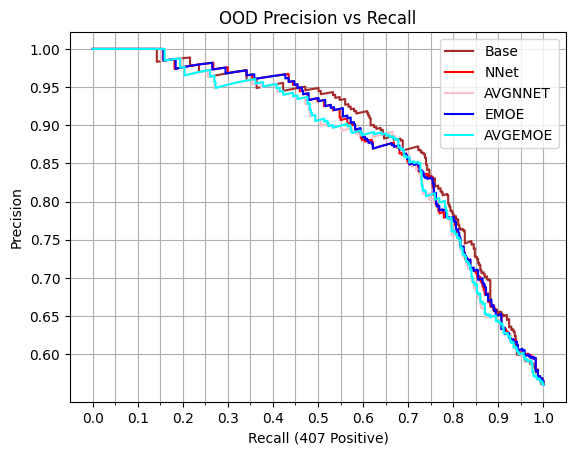

In [ ]:
true_Y = y_val_ood

# base model
confs = np.mean(base_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='brown')
BASE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
BASE_AUROC = metrics.roc_auc_score(true_Y, confs)
BASE_ACC = metrics.accuracy_score(true_Y, preds)

print('Base:\n{} (AUROC:{},ACC:{})'.format(BASE_AUPRC, BASE_AUROC,BASE_ACC))

# student model
confs = np.mean(model_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='red')
MOD_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
MOD_AUROC = metrics.roc_auc_score(true_Y, confs)
MOD_ACC = metrics.accuracy_score(true_Y, preds)
print('Model:\n{} (AUROC:{},ACC:{})'.format(MOD_AUPRC, MOD_AUROC,MOD_ACC))

# average student model
confs = np.mean(average_model_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='pink')
AVGMOD_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
AVGMOD_AUROC = metrics.roc_auc_score(true_Y, confs)
AVGMOD_ACC = metrics.accuracy_score(true_Y, preds)
print('Average Model:\n{} (AUROC:{},ACC:{})'.format(AVGMOD_AUPRC, AVGMOD_AUROC,AVGMOD_ACC))

# base+student model
confs = (np.mean(base_predictions, -1)+np.mean(model_predictions, -1))/2.
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='blue')
EMOE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
EMOE_AUROC = metrics.roc_auc_score(true_Y, confs)
EMOE_ACC = metrics.accuracy_score(true_Y, preds)
print('Base+Model:\n{} (AUROC:{},ACC:{})'.format(EMOE_AUPRC, EMOE_AUROC,EMOE_ACC))

# base+average student model
confs = (np.mean(base_predictions, -1)+np.mean(average_model_predictions, -1))/2.
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='cyan')
AVGEMOE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
AVGEMOE_AUROC = metrics.roc_auc_score(true_Y, confs)
AVGEMOE_ACC = metrics.accuracy_score(true_Y, preds)
print('Base+Average Model:\n{} (AUROC:{},ACC:{})'.format(AVGEMOE_AUPRC, AVGEMOE_AUROC,AVGEMOE_ACC))

plt.xticks(np.arange(0, 1.01, step=0.1))
plt.xticks(np.arange(0, 1.01, step=0.05), minor=True)
plt.yticks(np.arange(0.6, 1.01, step=0.05))
plt.grid(True, which='both')
plt.xlabel('Recall ({} Positive)'.format(int(np.sum(true_Y))))
plt.ylabel('Precision')
plt.title('OOD Precision vs Recall')
plt.legend(['Base', 'NNet', 'AVGNNET', 'EMOE', 'AVGEMOE'])
plt.show()

Loss at step 000: 0.178
Loss at step 100: 0.155
Getting Average Model (T=10)
Loss at step 200: 0.148
Getting Average Model (T=11)
Loss at step 300: 0.138
Getting Average Model (T=12)
Loss at step 400: 0.116
Getting Average Model (T=13)
Loss at step 500: 0.115
Getting Average Model (T=14)
Loss at step 600: 0.100
Getting Average Model (T=15)
Loss at step 700: 0.089
Getting Average Model (T=16)
Loss at step 800: 0.083
Getting Average Model (T=17)
Loss at step 900: 0.077
Getting Average Model (T=18)
Loss at step 1000: 0.064
Getting Average Model (T=19)
Base:
[1.         0.99589599 0.98839862 0.9815354  0.88675549] (AUROC:0.8393811425061424,ACC:0.7744154057771664)
Model:
[1.         0.99503344 0.98650965 0.98091885 0.88084702] (AUROC:0.8327702702702703,ACC:0.7702888583218707)
Average Model:
[1.         0.99564798 0.98852111 0.98187294 0.87817878] (AUROC:0.827203624078624,ACC:0.7730398899587345)
Base+Model:
[1.         0.99497509 0.98621406 0.98062094 0.88125373] (AUROC:0.8333154176904177,AC

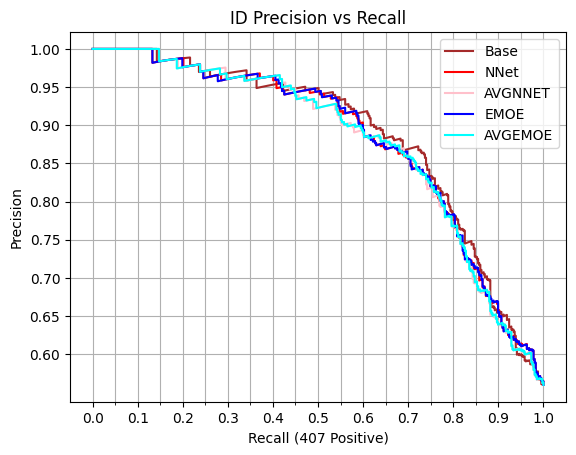

In [ ]:
avgint = 100
for i in range(1001):
  xb, xlbls = batch()
  xb_conf, xlbls_conf = batch_conf()
  # xb_unconf, xlbls_unconf = batch_unconf()
  grads = grad(model, xb, xlbls, xb_conf, xlbls_conf, alpha=alpha_rnd)
  optimizer.apply_gradients(zip(grads, model.trainable_variables))
  if i % 100 == 0:
    print("Loss at step {:03d}: {:.3f}".format(i, loss(model, xb, xlbls, xb_conf, xlbls_conf, alpha=alpha_rnd)))
  if i > 0 and i % avgint == 0:
    print('Getting Average Model (T={})'.format(T))
    for avgweights, weights in zip(average_model.trainable_variables, model.trainable_variables):
      avgweights.assign((T/(T+1.))*avgweights + (1./(T+1))*weights)
    T = T + 1
model_predictions = model.get_features(external_X)
average_model_predictions = average_model.get_features(external_X)
# true_Y = y_val_ood

# base model
confs = np.mean(base_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='brown')
BASE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
BASE_AUROC = metrics.roc_auc_score(true_Y, confs)
BASE_ACC = metrics.accuracy_score(true_Y, preds)

print('Base:\n{} (AUROC:{},ACC:{})'.format(BASE_AUPRC, BASE_AUROC,BASE_ACC))

# student model
confs = np.mean(model_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='red')
MOD_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
MOD_AUROC = metrics.roc_auc_score(true_Y, confs)
MOD_ACC = metrics.accuracy_score(true_Y, preds)
print('Model:\n{} (AUROC:{},ACC:{})'.format(MOD_AUPRC, MOD_AUROC,MOD_ACC))

# average student model
confs = np.mean(average_model_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='pink')
AVGMOD_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
AVGMOD_AUROC = metrics.roc_auc_score(true_Y, confs)
AVGMOD_ACC = metrics.accuracy_score(true_Y, preds)
print('Average Model:\n{} (AUROC:{},ACC:{})'.format(AVGMOD_AUPRC, AVGMOD_AUROC,AVGMOD_ACC))

# base+student model
confs = (np.mean(base_predictions, -1)+np.mean(model_predictions, -1))/2.
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='blue')
EMOE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
EMOE_AUROC = metrics.roc_auc_score(true_Y, confs)
EMOE_ACC = metrics.accuracy_score(true_Y, preds)
print('Base+Model:\n{} (AUROC:{},ACC:{})'.format(EMOE_AUPRC, EMOE_AUROC,EMOE_ACC))

# base+average student model
confs = (np.mean(base_predictions, -1)+np.mean(average_model_predictions, -1))/2.
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='cyan')
AVGEMOE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
AVGEMOE_AUROC = metrics.roc_auc_score(true_Y, confs)
AVGEMOE_ACC = metrics.accuracy_score(true_Y, preds)
print('Base+Average Model:\n{} (AUROC:{},ACC:{})'.format(AVGEMOE_AUPRC, AVGEMOE_AUROC,AVGEMOE_ACC))

plt.xticks(np.arange(0, 1.01, step=0.1))
plt.xticks(np.arange(0, 1.01, step=0.05), minor=True)
plt.yticks(np.arange(0.6, 1.01, step=0.05))
plt.grid(True, which='both')
plt.xlabel('Recall ({} Positive)'.format(int(np.sum(true_Y))))
plt.ylabel('Precision')
plt.title('ID Precision vs Recall')
plt.legend(['Base', 'NNet', 'AVGNNET', 'EMOE', 'AVGEMOE'])
plt.show()

Loss at step 000: 0.068
Getting Average Model (T=2)
Getting Average Model (T=3)
Getting Average Model (T=4)
Getting Average Model (T=5)
Getting Average Model (T=6)
Getting Average Model (T=7)
Getting Average Model (T=8)
Getting Average Model (T=9)
Getting Average Model (T=10)
Loss at step 1000: 0.022
Getting Average Model (T=11)
Base:
[1.         0.99589599 0.98839862 0.9815354  0.88675549] (AUROC:0.8393811425061424,ACC:0.7744154057771664)
Model:
[1.         0.99308196 0.98525863 0.97890582 0.88280476] (AUROC:0.8364097051597051,ACC:0.7757909215955984)
Average Model:
[1.         0.99191065 0.98379109 0.9781333  0.88248485] (AUROC:0.8359566953316953,ACC:0.7799174690508941)
Base+Model:
[1.         0.99330333 0.98555233 0.97909188 0.88307805] (AUROC:0.8366170147420147,ACC:0.7771664374140302)
Base+Average Model:
[1.         0.99223388 0.98409139 0.97843387 0.88281138] (AUROC:0.8361793611793613,ACC:0.7799174690508941)


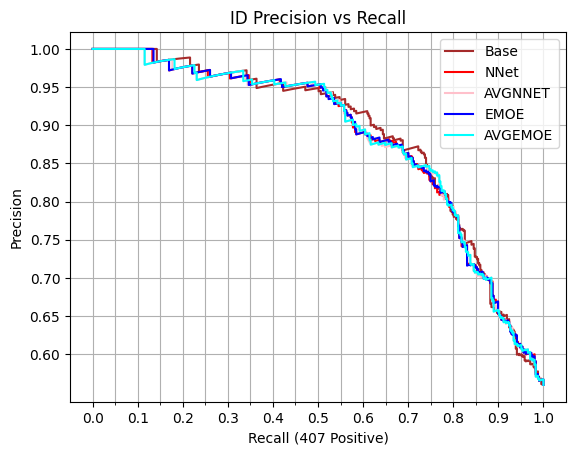

In [ ]:
avgint = 100
for i in range(1001):
  xb, xlbls = batch()
  xb_conf, xlbls_conf = batch_conf()
  # xb_unconf, xlbls_unconf = batch_unconf()
  grads = grad(model, xb, xlbls, xb_conf, xlbls_conf, alpha=alpha_rnd)
  optimizer.apply_gradients(zip(grads, model.trainable_variables))
  if i % 1000 == 0:
    print("Loss at step {:03d}: {:.3f}".format(i, loss(model, xb, xlbls, xb_conf, xlbls_conf, alpha=alpha_rnd)))
  if i > 0 and i % avgint == 0:
    print('Getting Average Model (T={})'.format(T))
    for avgweights, weights in zip(average_model.trainable_variables, model.trainable_variables):
      avgweights.assign((T/(T+1.))*avgweights + (1./(T+1))*weights)
    T = T + 1
model_predictions = model.get_features(external_X)
average_model_predictions = average_model.get_features(external_X)
# true_Y = y_val_ood

# base model
confs = np.mean(base_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='brown')
BASE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
BASE_AUROC = metrics.roc_auc_score(true_Y, confs)
BASE_ACC = metrics.accuracy_score(true_Y, preds)

print('Base:\n{} (AUROC:{},ACC:{})'.format(BASE_AUPRC, BASE_AUROC,BASE_ACC))

# student model
confs = np.mean(model_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='red')
MOD_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
MOD_AUROC = metrics.roc_auc_score(true_Y, confs)
MOD_ACC = metrics.accuracy_score(true_Y, preds)
print('Model:\n{} (AUROC:{},ACC:{})'.format(MOD_AUPRC, MOD_AUROC,MOD_ACC))

# average student model
confs = np.mean(average_model_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='pink')
AVGMOD_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
AVGMOD_AUROC = metrics.roc_auc_score(true_Y, confs)
AVGMOD_ACC = metrics.accuracy_score(true_Y, preds)
print('Average Model:\n{} (AUROC:{},ACC:{})'.format(AVGMOD_AUPRC, AVGMOD_AUROC,AVGMOD_ACC))

# base+student model
confs = (np.mean(base_predictions, -1)+np.mean(model_predictions, -1))/2.
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='blue')
EMOE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
EMOE_AUROC = metrics.roc_auc_score(true_Y, confs)
EMOE_ACC = metrics.accuracy_score(true_Y, preds)
print('Base+Model:\n{} (AUROC:{},ACC:{})'.format(EMOE_AUPRC, EMOE_AUROC,EMOE_ACC))

# base+average student model
confs = (np.mean(base_predictions, -1)+np.mean(average_model_predictions, -1))/2.
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='cyan')
AVGEMOE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
AVGEMOE_AUROC = metrics.roc_auc_score(true_Y, confs)
AVGEMOE_ACC = metrics.accuracy_score(true_Y, preds)
print('Base+Average Model:\n{} (AUROC:{},ACC:{})'.format(AVGEMOE_AUPRC, AVGEMOE_AUROC,AVGEMOE_ACC))

plt.xticks(np.arange(0, 1.01, step=0.1))
plt.xticks(np.arange(0, 1.01, step=0.05), minor=True)
plt.yticks(np.arange(0.6, 1.01, step=0.05))
plt.grid(True, which='both')
plt.xlabel('Recall ({} Positive)'.format(int(np.sum(true_Y))))
plt.ylabel('Precision')
plt.title('ID Precision vs Recall')
plt.legend(['Base', 'NNet', 'AVGNNET', 'EMOE', 'AVGEMOE'])
plt.show()

Loss at step 000: 0.001
Loss at step 1000: 0.002
Base:
[1.         0.99589599 0.98839862 0.9815354  0.88675549] (AUROC:0.8393811425061424,ACC:0.7744154057771664)
Model:
[1.         0.99319044 0.98426893 0.9740937  0.87544195] (AUROC:0.8289158476658476,ACC:0.7592847317744154)
Average Model:
[1.         0.99392224 0.98561609 0.97768199 0.87664329] (AUROC:0.8288774570024571,ACC:0.7606602475928473)
Base+Model:
[1.         0.99319044 0.98419353 0.97412104 0.87558606] (AUROC:0.8290540540540541,ACC:0.7592847317744154)
Base+Average Model:
[1.         0.99392224 0.98561609 0.97786714 0.87703521] (AUROC:0.829222972972973,ACC:0.7620357634112792)


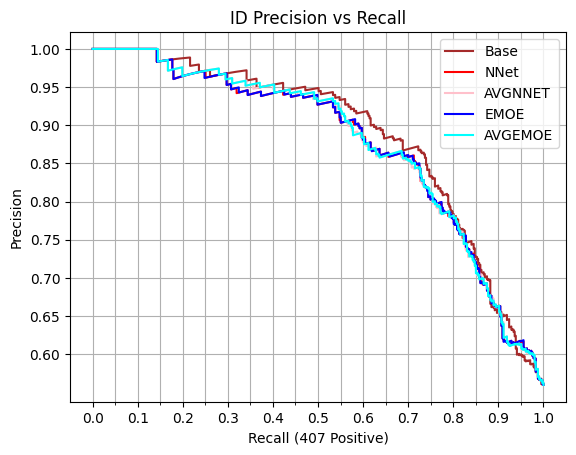

In [ ]:
avgint = 5000
for i in range(1001):
  xb, xlbls = batch()
  xb_conf, xlbls_conf = batch_conf()
  # xb_unconf, xlbls_unconf = batch_unconf()
  grads = grad(model, xb, xlbls, xb_conf, xlbls_conf, alpha=alpha_rnd)
  optimizer.apply_gradients(zip(grads, model.trainable_variables))
  if i % 1000 == 0:
    print("Loss at step {:03d}: {:.3f}".format(i, loss(model, xb, xlbls, xb_conf, xlbls_conf, alpha=alpha_rnd)))
  if i > 0 and i % avgint == 0:
    print('Getting Average Model (T={})'.format(T))
    for avgweights, weights in zip(average_model.trainable_variables, model.trainable_variables):
      avgweights.assign((T/(T+1.))*avgweights + (1./(T+1))*weights)
    T = T + 1
model_predictions = model.get_features(external_X)
average_model_predictions = average_model.get_features(external_X)
# true_Y = y_val_ood

# base model
confs = np.mean(base_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='brown')
BASE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
BASE_AUROC = metrics.roc_auc_score(true_Y, confs)
BASE_ACC = metrics.accuracy_score(true_Y, preds)

print('Base:\n{} (AUROC:{},ACC:{})'.format(BASE_AUPRC, BASE_AUROC,BASE_ACC))

# student model
confs = np.mean(model_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='red')
MOD_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
MOD_AUROC = metrics.roc_auc_score(true_Y, confs)
MOD_ACC = metrics.accuracy_score(true_Y, preds)
print('Model:\n{} (AUROC:{},ACC:{})'.format(MOD_AUPRC, MOD_AUROC,MOD_ACC))

# average student model
confs = np.mean(average_model_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='pink')
AVGMOD_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
AVGMOD_AUROC = metrics.roc_auc_score(true_Y, confs)
AVGMOD_ACC = metrics.accuracy_score(true_Y, preds)
print('Average Model:\n{} (AUROC:{},ACC:{})'.format(AVGMOD_AUPRC, AVGMOD_AUROC,AVGMOD_ACC))

# base+student model
confs = (np.mean(base_predictions, -1)+np.mean(model_predictions, -1))/2.
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='blue')
EMOE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
EMOE_AUROC = metrics.roc_auc_score(true_Y, confs)
EMOE_ACC = metrics.accuracy_score(true_Y, preds)
print('Base+Model:\n{} (AUROC:{},ACC:{})'.format(EMOE_AUPRC, EMOE_AUROC,EMOE_ACC))

# base+average student model
confs = (np.mean(base_predictions, -1)+np.mean(average_model_predictions, -1))/2.
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='cyan')
AVGEMOE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
AVGEMOE_AUROC = metrics.roc_auc_score(true_Y, confs)
AVGEMOE_ACC = metrics.accuracy_score(true_Y, preds)
print('Base+Average Model:\n{} (AUROC:{},ACC:{})'.format(AVGEMOE_AUPRC, AVGEMOE_AUROC,AVGEMOE_ACC))

plt.xticks(np.arange(0, 1.01, step=0.1))
plt.xticks(np.arange(0, 1.01, step=0.05), minor=True)
plt.yticks(np.arange(0.6, 1.01, step=0.05))
plt.grid(True, which='both')
plt.xlabel('Recall ({} Positive)'.format(int(np.sum(true_Y))))
plt.ylabel('Precision')
plt.title('ID Precision vs Recall')
plt.legend(['Base', 'NNet', 'AVGNNET', 'EMOE', 'AVGEMOE'])
plt.show()

Loss at step 000: 0.002
Loss at step 1000: 0.002
Base:
[1.         0.99589599 0.98839862 0.9815354  0.88675549] (AUROC:0.8393811425061424,ACC:0.7744154057771664)
Model:
[1.         0.9944786  0.98664932 0.97765244 0.87687537] (AUROC:0.8290540540540541,ACC:0.7551581843191196)
Average Model:
[1.         0.99392224 0.98561609 0.97768199 0.87664329] (AUROC:0.8288774570024571,ACC:0.7606602475928473)
Base+Model:
[1.         0.99467914 0.98683331 0.97781386 0.87708377] (AUROC:0.8292536855036856,ACC:0.7551581843191196)
Base+Average Model:
[1.         0.99392224 0.98561609 0.97786714 0.87703521] (AUROC:0.829222972972973,ACC:0.7620357634112792)


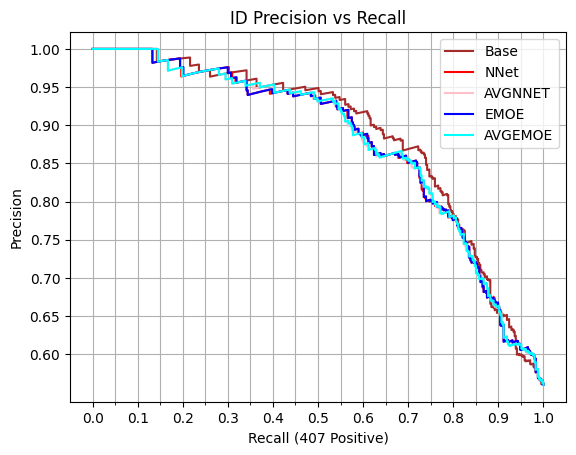

In [ ]:
avgint = 10000
for i in range(1001):
  xb, xlbls = batch()
  xb_conf, xlbls_conf = batch_conf()
  # xb_unconf, xlbls_unconf = batch_unconf()
  grads = grad(model, xb, xlbls, xb_conf, xlbls_conf, alpha=alpha_rnd)
  optimizer.apply_gradients(zip(grads, model.trainable_variables))
  if i % 1000 == 0:
    print("Loss at step {:03d}: {:.3f}".format(i, loss(model, xb, xlbls, xb_conf, xlbls_conf, alpha=alpha_rnd)))
  if i > 0 and i % avgint == 0:
    print('Getting Average Model (T={})'.format(T))
    for avgweights, weights in zip(average_model.trainable_variables, model.trainable_variables):
      avgweights.assign((T/(T+1.))*avgweights + (1./(T+1))*weights)
    T = T + 1
model_predictions = model.get_features(external_X)
average_model_predictions = average_model.get_features(external_X)
# true_Y = y_val_ood

# base model
confs = np.mean(base_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='brown')
BASE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
BASE_AUROC = metrics.roc_auc_score(true_Y, confs)
BASE_ACC = metrics.accuracy_score(true_Y, preds)

print('Base:\n{} (AUROC:{},ACC:{})'.format(BASE_AUPRC, BASE_AUROC,BASE_ACC))

# student model
confs = np.mean(model_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='red')
MOD_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
MOD_AUROC = metrics.roc_auc_score(true_Y, confs)
MOD_ACC = metrics.accuracy_score(true_Y, preds)
print('Model:\n{} (AUROC:{},ACC:{})'.format(MOD_AUPRC, MOD_AUROC,MOD_ACC))

# average student model
confs = np.mean(average_model_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='pink')
AVGMOD_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
AVGMOD_AUROC = metrics.roc_auc_score(true_Y, confs)
AVGMOD_ACC = metrics.accuracy_score(true_Y, preds)
print('Average Model:\n{} (AUROC:{},ACC:{})'.format(AVGMOD_AUPRC, AVGMOD_AUROC,AVGMOD_ACC))

# base+student model
confs = (np.mean(base_predictions, -1)+np.mean(model_predictions, -1))/2.
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='blue')
EMOE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
EMOE_AUROC = metrics.roc_auc_score(true_Y, confs)
EMOE_ACC = metrics.accuracy_score(true_Y, preds)
print('Base+Model:\n{} (AUROC:{},ACC:{})'.format(EMOE_AUPRC, EMOE_AUROC,EMOE_ACC))

# base+average student model
confs = (np.mean(base_predictions, -1)+np.mean(average_model_predictions, -1))/2.
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='cyan')
AVGEMOE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
AVGEMOE_AUROC = metrics.roc_auc_score(true_Y, confs)
AVGEMOE_ACC = metrics.accuracy_score(true_Y, preds)
print('Base+Average Model:\n{} (AUROC:{},ACC:{})'.format(AVGEMOE_AUPRC, AVGEMOE_AUROC,AVGEMOE_ACC))

plt.xticks(np.arange(0, 1.01, step=0.1))
plt.xticks(np.arange(0, 1.01, step=0.05), minor=True)
plt.yticks(np.arange(0.6, 1.01, step=0.05))
plt.grid(True, which='both')
plt.xlabel('Recall ({} Positive)'.format(int(np.sum(true_Y))))
plt.ylabel('Precision')
plt.title('ID Precision vs Recall')
plt.legend(['Base', 'NNet', 'AVGNNET', 'EMOE', 'AVGEMOE'])
plt.show()

Loss at step 000: 0.001
Loss at step 1000: 0.003
Base:
[1.         0.99589599 0.98839862 0.9815354  0.88675549] (AUROC:0.8393811425061424,ACC:0.7744154057771664)
Model:
[1.         0.99523843 0.9856812  0.97785728 0.87602189] (AUROC:0.8278178746928747,ACC:0.7579092159559835)
Average Model:
[1.         0.99392224 0.98561609 0.97768199 0.87664329] (AUROC:0.8288774570024571,ACC:0.7606602475928473)
Base+Model:
[1.         0.99523843 0.98573091 0.97785928 0.87614853] (AUROC:0.8279714373464373,ACC:0.7579092159559835)
Base+Average Model:
[1.         0.99392224 0.98561609 0.97786714 0.87703521] (AUROC:0.829222972972973,ACC:0.7620357634112792)


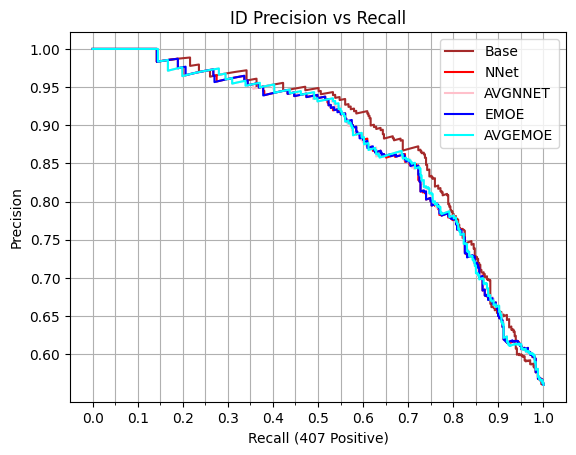

In [ ]:
avgint = 5000
for i in range(1001):
  xb, xlbls = batch()
  xb_conf, xlbls_conf = batch_conf()
  # xb_unconf, xlbls_unconf = batch_unconf()
  grads = grad(model, xb, xlbls, xb_conf, xlbls_conf, alpha=alpha_rnd)
  optimizer.apply_gradients(zip(grads, model.trainable_variables))
  if i % 1000 == 0:
    print("Loss at step {:03d}: {:.3f}".format(i, loss(model, xb, xlbls, xb_conf, xlbls_conf, alpha=alpha_rnd)))
  if i > 0 and i % avgint == 0:
    print('Getting Average Model (T={})'.format(T))
    for avgweights, weights in zip(average_model.trainable_variables, model.trainable_variables):
      avgweights.assign((T/(T+1.))*avgweights + (1./(T+1))*weights)
    T = T + 1
model_predictions = model.get_features(external_X)
average_model_predictions = average_model.get_features(external_X)
# true_Y = y_val_ood

# base model
confs = np.mean(base_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='brown')
BASE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
BASE_AUROC = metrics.roc_auc_score(true_Y, confs)
BASE_ACC = metrics.accuracy_score(true_Y, preds)

print('Base:\n{} (AUROC:{},ACC:{})'.format(BASE_AUPRC, BASE_AUROC,BASE_ACC))

# student model
confs = np.mean(model_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='red')
MOD_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
MOD_AUROC = metrics.roc_auc_score(true_Y, confs)
MOD_ACC = metrics.accuracy_score(true_Y, preds)
print('Model:\n{} (AUROC:{},ACC:{})'.format(MOD_AUPRC, MOD_AUROC,MOD_ACC))

# average student model
confs = np.mean(average_model_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='pink')
AVGMOD_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
AVGMOD_AUROC = metrics.roc_auc_score(true_Y, confs)
AVGMOD_ACC = metrics.accuracy_score(true_Y, preds)
print('Average Model:\n{} (AUROC:{},ACC:{})'.format(AVGMOD_AUPRC, AVGMOD_AUROC,AVGMOD_ACC))

# base+student model
confs = (np.mean(base_predictions, -1)+np.mean(model_predictions, -1))/2.
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='blue')
EMOE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
EMOE_AUROC = metrics.roc_auc_score(true_Y, confs)
EMOE_ACC = metrics.accuracy_score(true_Y, preds)
print('Base+Model:\n{} (AUROC:{},ACC:{})'.format(EMOE_AUPRC, EMOE_AUROC,EMOE_ACC))

# base+average student model
confs = (np.mean(base_predictions, -1)+np.mean(average_model_predictions, -1))/2.
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='cyan')
AVGEMOE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
AVGEMOE_AUROC = metrics.roc_auc_score(true_Y, confs)
AVGEMOE_ACC = metrics.accuracy_score(true_Y, preds)
print('Base+Average Model:\n{} (AUROC:{},ACC:{})'.format(AVGEMOE_AUPRC, AVGEMOE_AUROC,AVGEMOE_ACC))

plt.xticks(np.arange(0, 1.01, step=0.1))
plt.xticks(np.arange(0, 1.01, step=0.05), minor=True)
plt.yticks(np.arange(0.6, 1.01, step=0.05))
plt.grid(True, which='both')
plt.xlabel('Recall ({} Positive)'.format(int(np.sum(true_Y))))
plt.ylabel('Precision')
plt.title('ID Precision vs Recall')
plt.legend(['Base', 'NNet', 'AVGNNET', 'EMOE', 'AVGEMOE'])
plt.show()

Loss at step 000: 0.000
Loss at step 1000: 0.000
Base:
[1.         0.99589599 0.98839862 0.9815354  0.88675549] (AUROC:0.8393811425061424,ACC:0.7744154057771664)
Model:
[1.         0.99470001 0.9859923  0.97669936 0.87586839] (AUROC:0.8287929975429975,ACC:0.7537826685006878)
Average Model:
[1.         0.99392224 0.98561609 0.97768199 0.87664329] (AUROC:0.8288774570024571,ACC:0.7606602475928473)
Base+Model:
[1.         0.99470001 0.98592266 0.97664713 0.87599193] (AUROC:0.828992628992629,ACC:0.7579092159559835)
Base+Average Model:
[1.         0.99392224 0.98561609 0.97786714 0.87703521] (AUROC:0.829222972972973,ACC:0.7620357634112792)


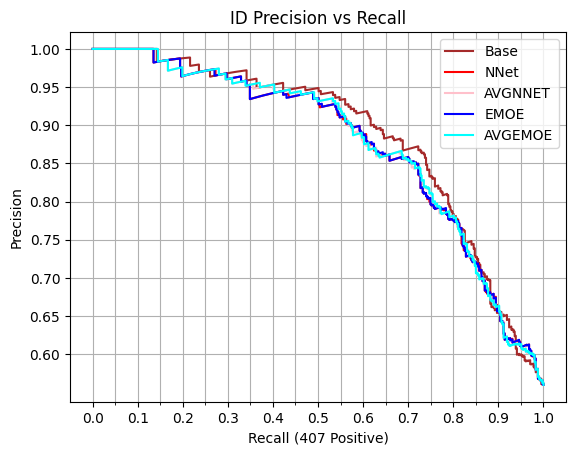

In [ ]:
avgint = 5000
for i in range(1001):
  xb, xlbls = batch()
  xb_conf, xlbls_conf = batch_conf()
  # xb_unconf, xlbls_unconf = batch_unconf()
  grads = grad(model, xb, xlbls, xb_conf, xlbls_conf, alpha=alpha_rnd)
  optimizer.apply_gradients(zip(grads, model.trainable_variables))
  if i % 1000 == 0:
    print("Loss at step {:03d}: {:.3f}".format(i, loss(model, xb, xlbls, xb_conf, xlbls_conf, alpha=alpha_rnd)))
  if i > 0 and i % avgint == 0:
    print('Getting Average Model (T={})'.format(T))
    for avgweights, weights in zip(average_model.trainable_variables, model.trainable_variables):
      avgweights.assign((T/(T+1.))*avgweights + (1./(T+1))*weights)
    T = T + 1
model_predictions = model.get_features(external_X)
average_model_predictions = average_model.get_features(external_X)
# true_Y = y_val_ood

# base model
confs = np.mean(base_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='brown')
BASE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
BASE_AUROC = metrics.roc_auc_score(true_Y, confs)
BASE_ACC = metrics.accuracy_score(true_Y, preds)

print('Base:\n{} (AUROC:{},ACC:{})'.format(BASE_AUPRC, BASE_AUROC,BASE_ACC))

# student model
confs = np.mean(model_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='red')
MOD_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
MOD_AUROC = metrics.roc_auc_score(true_Y, confs)
MOD_ACC = metrics.accuracy_score(true_Y, preds)
print('Model:\n{} (AUROC:{},ACC:{})'.format(MOD_AUPRC, MOD_AUROC,MOD_ACC))

# average student model
confs = np.mean(average_model_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='pink')
AVGMOD_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
AVGMOD_AUROC = metrics.roc_auc_score(true_Y, confs)
AVGMOD_ACC = metrics.accuracy_score(true_Y, preds)
print('Average Model:\n{} (AUROC:{},ACC:{})'.format(AVGMOD_AUPRC, AVGMOD_AUROC,AVGMOD_ACC))

# base+student model
confs = (np.mean(base_predictions, -1)+np.mean(model_predictions, -1))/2.
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='blue')
EMOE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
EMOE_AUROC = metrics.roc_auc_score(true_Y, confs)
EMOE_ACC = metrics.accuracy_score(true_Y, preds)
print('Base+Model:\n{} (AUROC:{},ACC:{})'.format(EMOE_AUPRC, EMOE_AUROC,EMOE_ACC))

# base+average student model
confs = (np.mean(base_predictions, -1)+np.mean(average_model_predictions, -1))/2.
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='cyan')
AVGEMOE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
AVGEMOE_AUROC = metrics.roc_auc_score(true_Y, confs)
AVGEMOE_ACC = metrics.accuracy_score(true_Y, preds)
print('Base+Average Model:\n{} (AUROC:{},ACC:{})'.format(AVGEMOE_AUPRC, AVGEMOE_AUROC,AVGEMOE_ACC))

plt.xticks(np.arange(0, 1.01, step=0.1))
plt.xticks(np.arange(0, 1.01, step=0.05), minor=True)
plt.yticks(np.arange(0.6, 1.01, step=0.05))
plt.grid(True, which='both')
plt.xlabel('Recall ({} Positive)'.format(int(np.sum(true_Y))))
plt.ylabel('Precision')
plt.title('ID Precision vs Recall')
plt.legend(['Base', 'NNet', 'AVGNNET', 'EMOE', 'AVGEMOE'])
plt.show()

Loss at step 000: 0.000
Loss at step 1000: 0.000
Base:
[1.         0.99589599 0.98839862 0.9815354  0.88675549] (AUROC:0.8393811425061424,ACC:0.7744154057771664)
Model:
[1.         0.9963056  0.98752093 0.97811149 0.87666522] (AUROC:0.8296606265356266,ACC:0.7565337001375516)
Average Model:
[1.         0.99392224 0.98561609 0.97768199 0.87664329] (AUROC:0.8288774570024571,ACC:0.7606602475928473)
Base+Model:
[1.         0.9963056  0.98752093 0.97825952 0.87683613] (AUROC:0.829806511056511,ACC:0.7565337001375516)
Base+Average Model:
[1.         0.99392224 0.98561609 0.97786714 0.87703521] (AUROC:0.829222972972973,ACC:0.7620357634112792)


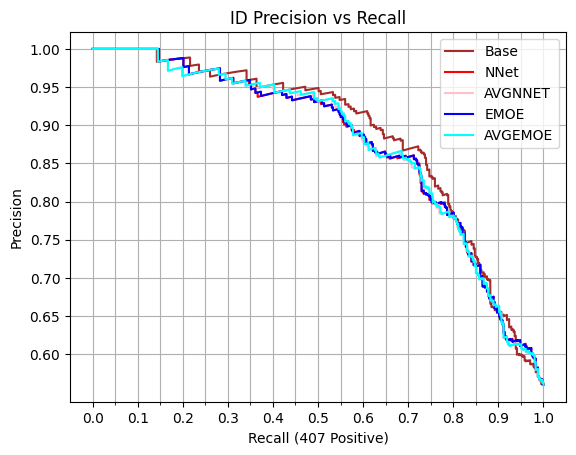

In [ ]:
avgint = 5000
for i in range(1001):
  xb, xlbls = batch()
  xb_conf, xlbls_conf = batch_conf()
  # xb_unconf, xlbls_unconf = batch_unconf()
  grads = grad(model, xb, xlbls, xb_conf, xlbls_conf, alpha=alpha_rnd)
  optimizer.apply_gradients(zip(grads, model.trainable_variables))
  if i % 1000 == 0:
    print("Loss at step {:03d}: {:.3f}".format(i, loss(model, xb, xlbls, xb_conf, xlbls_conf, alpha=alpha_rnd)))
  if i > 0 and i % avgint == 0:
    print('Getting Average Model (T={})'.format(T))
    for avgweights, weights in zip(average_model.trainable_variables, model.trainable_variables):
      avgweights.assign((T/(T+1.))*avgweights + (1./(T+1))*weights)
    T = T + 1
model_predictions = model.get_features(external_X)
average_model_predictions = average_model.get_features(external_X)
# true_Y = y_val_ood

# base model
confs = np.mean(base_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='brown')
BASE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
BASE_AUROC = metrics.roc_auc_score(true_Y, confs)
BASE_ACC = metrics.accuracy_score(true_Y, preds)

print('Base:\n{} (AUROC:{},ACC:{})'.format(BASE_AUPRC, BASE_AUROC,BASE_ACC))

# student model
confs = np.mean(model_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='red')
MOD_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
MOD_AUROC = metrics.roc_auc_score(true_Y, confs)
MOD_ACC = metrics.accuracy_score(true_Y, preds)
print('Model:\n{} (AUROC:{},ACC:{})'.format(MOD_AUPRC, MOD_AUROC,MOD_ACC))

# average student model
confs = np.mean(average_model_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='pink')
AVGMOD_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
AVGMOD_AUROC = metrics.roc_auc_score(true_Y, confs)
AVGMOD_ACC = metrics.accuracy_score(true_Y, preds)
print('Average Model:\n{} (AUROC:{},ACC:{})'.format(AVGMOD_AUPRC, AVGMOD_AUROC,AVGMOD_ACC))

# base+student model
confs = (np.mean(base_predictions, -1)+np.mean(model_predictions, -1))/2.
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='blue')
EMOE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
EMOE_AUROC = metrics.roc_auc_score(true_Y, confs)
EMOE_ACC = metrics.accuracy_score(true_Y, preds)
print('Base+Model:\n{} (AUROC:{},ACC:{})'.format(EMOE_AUPRC, EMOE_AUROC,EMOE_ACC))

# base+average student model
confs = (np.mean(base_predictions, -1)+np.mean(average_model_predictions, -1))/2.
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='cyan')
AVGEMOE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
AVGEMOE_AUROC = metrics.roc_auc_score(true_Y, confs)
AVGEMOE_ACC = metrics.accuracy_score(true_Y, preds)
print('Base+Average Model:\n{} (AUROC:{},ACC:{})'.format(AVGEMOE_AUPRC, AVGEMOE_AUROC,AVGEMOE_ACC))

plt.xticks(np.arange(0, 1.01, step=0.1))
plt.xticks(np.arange(0, 1.01, step=0.05), minor=True)
plt.yticks(np.arange(0.6, 1.01, step=0.05))
plt.grid(True, which='both')
plt.xlabel('Recall ({} Positive)'.format(int(np.sum(true_Y))))
plt.ylabel('Precision')
plt.title('ID Precision vs Recall')
plt.legend(['Base', 'NNet', 'AVGNNET', 'EMOE', 'AVGEMOE'])
plt.show()

In [ ]:
avgint = 5000
for i in range(1001):
  xb, xlbls = batch()
  xb_conf, xlbls_conf = batch_conf()
  # xb_unconf, xlbls_unconf = batch_unconf()
  grads = grad(model, xb, xlbls, xb_conf, xlbls_conf, alpha=alpha_rnd)
  optimizer.apply_gradients(zip(grads, model.trainable_variables))
  if i % 1000 == 0:
    print("Loss at step {:03d}: {:.3f}".format(i, loss(model, xb, xlbls, xb_conf, xlbls_conf, alpha=alpha_rnd)))
  if i > 0 and i % avgint == 0:
    print('Getting Average Model (T={})'.format(T))
    for avgweights, weights in zip(average_model.trainable_variables, model.trainable_variables):
      avgweights.assign((T/(T+1.))*avgweights + (1./(T+1))*weights)
    T = T + 1
model_predictions = model.get_features(external_X)
average_model_predictions = average_model.get_features(external_X)
# true_Y = y_val_ood

# base model
confs = np.mean(base_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='brown')
BASE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
BASE_AUROC = metrics.roc_auc_score(true_Y, confs)
BASE_ACC = metrics.accuracy_score(true_Y, preds)

print('Base:\n{} (AUROC:{},ACC:{})'.format(BASE_AUPRC, BASE_AUROC,BASE_ACC))

# student model
confs = np.mean(model_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='red')
MOD_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
MOD_AUROC = metrics.roc_auc_score(true_Y, confs)
MOD_ACC = metrics.accuracy_score(true_Y, preds)
print('Model:\n{} (AUROC:{},ACC:{})'.format(MOD_AUPRC, MOD_AUROC,MOD_ACC))

# average student model
confs = np.mean(average_model_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='pink')
AVGMOD_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
AVGMOD_AUROC = metrics.roc_auc_score(true_Y, confs)
AVGMOD_ACC = metrics.accuracy_score(true_Y, preds)
print('Average Model:\n{} (AUROC:{},ACC:{})'.format(AVGMOD_AUPRC, AVGMOD_AUROC,AVGMOD_ACC))

# base+student model
confs = (np.mean(base_predictions, -1)+np.mean(model_predictions, -1))/2.
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='blue')
EMOE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
EMOE_AUROC = metrics.roc_auc_score(true_Y, confs)
EMOE_ACC = metrics.accuracy_score(true_Y, preds)
print('Base+Model:\n{} (AUROC:{},ACC:{})'.format(EMOE_AUPRC, EMOE_AUROC,EMOE_ACC))

# base+average student model
confs = (np.mean(base_predictions, -1)+np.mean(average_model_predictions, -1))/2.
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='cyan')
AVGEMOE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
AVGEMOE_AUROC = metrics.roc_auc_score(true_Y, confs)
AVGEMOE_ACC = metrics.accuracy_score(true_Y, preds)
print('Base+Average Model:\n{} (AUROC:{},ACC:{})'.format(AVGEMOE_AUPRC, AVGEMOE_AUROC,AVGEMOE_ACC))

plt.xticks(np.arange(0, 1.01, step=0.1))
plt.xticks(np.arange(0, 1.01, step=0.05), minor=True)
plt.yticks(np.arange(0.6, 1.01, step=0.05))
plt.grid(True, which='both')
plt.xlabel('Recall ({} Positive)'.format(int(np.sum(true_Y))))
plt.ylabel('Precision')
plt.title('ID Precision vs Recall')
plt.legend(['Base', 'NNet', 'AVGNNET', 'EMOE', 'AVGEMOE'])
plt.show()

Loss at step 000: 0.001


KeyboardInterrupt: 